# Volleyball Data Analysis (VNL 2023)

## Objective
The goal of this analysis is to explore player performance in the 2023 Volleyball Nations League dataset. 

This includes:
- Understanding the distribution of key performance metrics (Attack, Block, Serve, Dig)
- Identifying relationships between features
- Comparing performance across countries, player positions, and age groups
- Extracting insights that can explain performance patterns among players

## Dataset Description
The dataset contains statistics of volleyball players, including:
- Country
- Player Position
- Age
- Performance metrics (Attack, Block, Serve, Dig)

## Tools Used
- Python
- Pandas
- Matplotlib / Seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('VNL2023.csv')

## Data Overview

In this section, we explore the structure of the dataset to understand its size, features, and data types.

In [3]:
df.head()

,Player,Country,Age,Attack,Block,Serve,Set,Dig,Receive,Position
0,Ichikawa Yuki,Japan,28,15.80,1.13,1.40,0.07,4.80,5.60,OH
1,Romano Yuri,Italy,26,12.33,1.07,1.47,0.00,3.87,0.00,OP
2,Abdel-Aziz Nimir,Nederland,31,15.33,0.67,2.08,0.00,3.17,0.25,OP
3,Herrera Jaime Jesus,Cuba,28,15.00,0.92,1.75,0.00,3.33,0.17,OP
4,Takahashi Ran,Japan,22,11.53,0.67,1.00,0.07,6.40,5.07,OH


In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Player    131 non-null    object 
 1   Country   131 non-null    object 
 2   Age       131 non-null    int64  
 3   Attack    131 non-null    float64
 4   Block     131 non-null    float64
 5   Serve     131 non-null    float64
 6   Set       131 non-null    float64
 7   Dig       131 non-null    float64
 8   Receive   131 non-null    float64
 9   Position  131 non-null    object 
dtypes: float64(6), int64(1), object(3)
memory usage: 10.4+ KB


In [5]:
df.describe()

,Age,Attack,Block,Serve,Set,Dig,Receive
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,27.809160,5.642672,0.845573,0.535802,2.192595,3.428397,1.684198
std,4.186268,4.256229,0.700896,0.454346,6.031587,2.077823,1.989939
min,19.000000,0.000000,0.000000,0.000000,0.000000,0.530000,0.000000
25%,25.000000,2.800000,0.370000,0.240000,0.000000,1.920000,0.000000
50%,27.000000,5.170000,0.690000,0.420000,0.000000,3.000000,0.330000
75%,30.000000,8.600000,1.140000,0.760000,0.000000,4.510000,3.385000
max,41.000000,15.800000,4.080000,2.080000,26.890000,11.440000,6.690000


### Observations:
- The dataset contains 131 rows and 10 columns
- Features include both categorical (player, Country, Position) and numerical variables ( Age, Attack, Block, Serve, Set, Dig and Recieve)
- Data types appear appropriate / may need adjustment (if any)

## Data Cleaning

In this section, we check for missing values, duplicates, and inconsistencies in the dataset.

In [6]:
df.isna().sum()

Player      0
Country     0
Age         0
Attack      0
Block       0
Serve       0
Set         0
Dig         0
Receive     0
Position    0
dtype: int64

### Missing Values Insight:
- The dataset contains no missing values, indicating it is relatively clean

In [7]:
df.duplicated().sum()

np.int64(0)

### Duplicate Records:
- There are no duplicate rows in the dataset

In [8]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)

              Age    Attack     Block     Serve       Set       Dig   Receive
Age      1.000000 -0.177849 -0.101040 -0.108367  0.177757  0.167141 -0.011067
Attack  -0.177849  1.000000  0.338412  0.768859 -0.430805 -0.098999  0.169892
Block   -0.101040  0.338412  1.000000  0.335954 -0.132019 -0.348347 -0.265206
Serve   -0.108367  0.768859  0.335954  1.000000 -0.154815 -0.052501  0.039642
Set      0.177757 -0.430805 -0.132019 -0.154815  1.000000  0.131659 -0.305869
Dig      0.167141 -0.098999 -0.348347 -0.052501  0.131659  1.000000  0.624733
Receive -0.011067  0.169892 -0.265206  0.039642 -0.305869  0.624733  1.000000


## Univariate Analysis

In this section, we analyze individual variables to understand their distribution and identify patterns in player performance metrics.

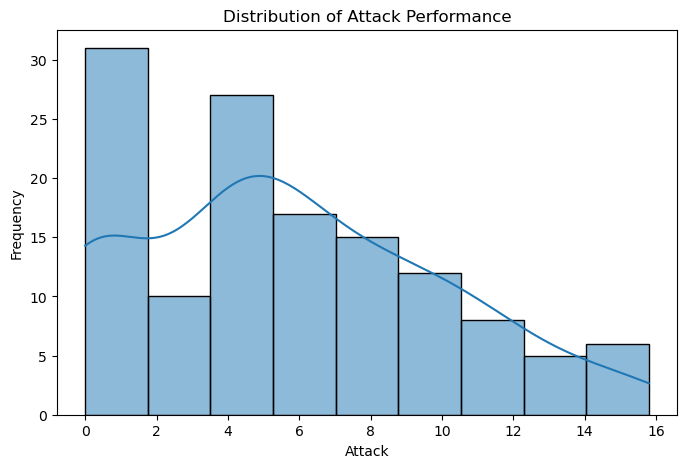

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Attack'], kde=True)
plt.title('Distribution of Attack Performance')
plt.xlabel('Attack')
plt.ylabel('Frequency')
plt.show()

### Insight:
- The distribution of attack performance appears: Right-skewed (or positively skewed). The data is heavily concentrated on the left side, with a long tail tapering off to the right.
- Most players have attack values between 0 and 8
- A few players have exceptionally high values: indicating possible outliers or a "high-tier" group. While most players are under 8, a small fraction of the population reaches values between 14 and 16, which is significantly higher than the dataset's average.

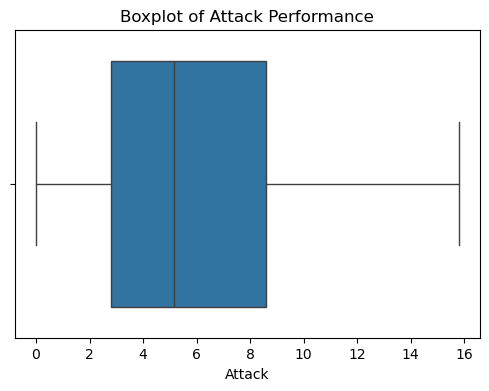

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Attack'])
plt.title('Boxplot of Attack Performance')
plt.show()

- The median attack performance is approximately 5.

- The middle 50% of players have attack values between 3 and 8.5.

- There are no statistical outliers detected, despite the high values reaching near 16, suggesting a wide but continuous range of performance.

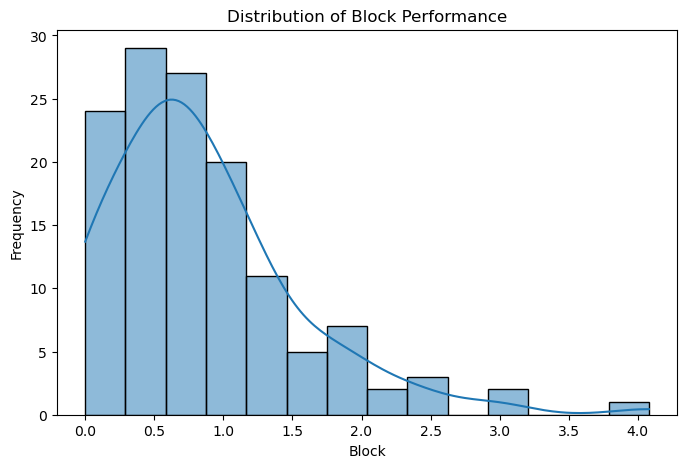

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Block'], kde=True)
plt.title('Distribution of Block Performance')
plt.xlabel('Block')
plt.ylabel('Frequency')
plt.show()

- The distribution of block performance appears: Highly right-skewed with a long tail.

- Most players have block values between: 0.0 and 1.0.

- A few players have values near 4.0: These are likely outliers, as they sit far apart from the general population.

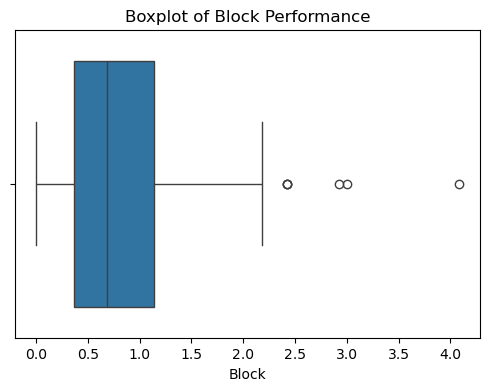

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Block'])
plt.title('Boxplot of Block Performance')
plt.show()

- The median block performance is approximately 0.7.

- The middle 50% of players have block values between 0.4 and 1.1.

- There are clear statistical outliers, with a few players achieving exceptionally high values between 2.4 and 4.1

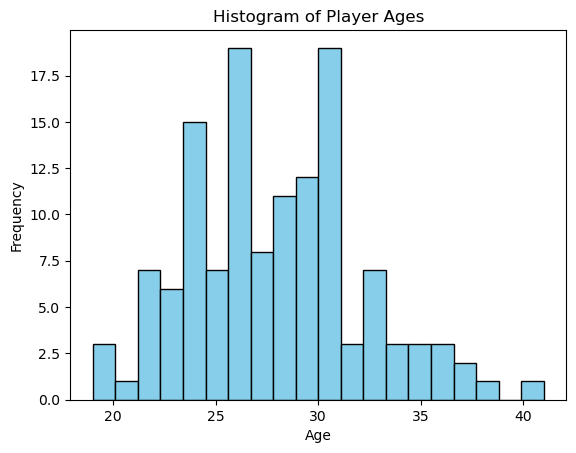

In [13]:
plt.hist(df['Age'], bins = 20, color = 'skyblue', edgecolor = 'black')
plt.title('Histogram of Player Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

- The distribution of player ages appears: Roughly symmetric/Bimodal, centered around the late 20s.

- Most players are aged between: 23 and 33.

- A few players are over 40: indicating they are the "veterans" of the group, but they are rare compared to the core demographic.

In [15]:
position_counts = df['Position'].value_counts()
position_counts.index

Index(['OH', 'MB', 'OP', 'S', 'L'], dtype='object', name='Position')

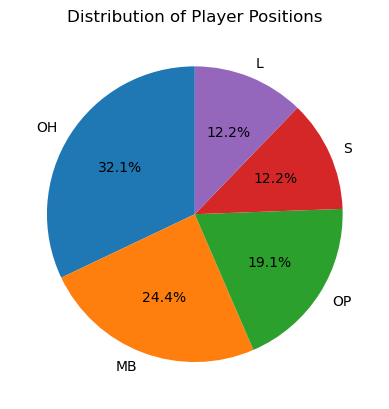

In [16]:
plt.pie(position_counts, labels = position_counts.index,autopct = '%1.1f%%',startangle = 90)
plt.title('Distribution of Player Positions')
plt.show()

- The most common player position is: OH (32.1%), followed by MB (24.4%).

- The least common positions are: S and L, which both represent only 12.2% of the players.

- Categorical Balance: The dataset favors offensive and net-defensive roles (OH/MB/OP) over specialized support roles (S/L).

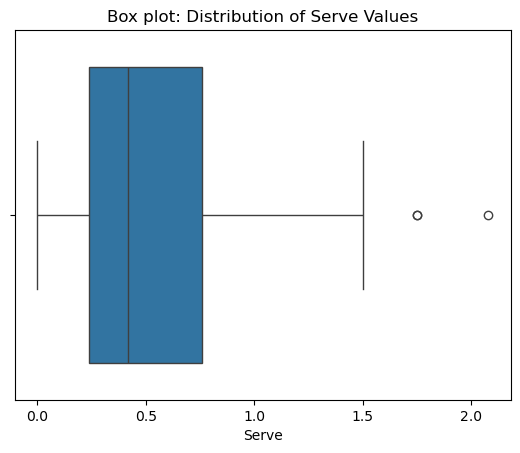

In [17]:
sns.boxplot(x = df['Serve'])
plt.title('Box plot: Distribution of Serve Values')
plt.xlabel('Serve')
plt.show()

- The median serve value is approximately 0.45.

- The middle 50% of players have serve values between 0.25 and 0.75.

- There are two significant outliers, with top serve values reaching 1.75 and 2.1.

## Bivariate Analysis

In this section, we examine relationships between variables to identify patterns and dependencies in player performance.

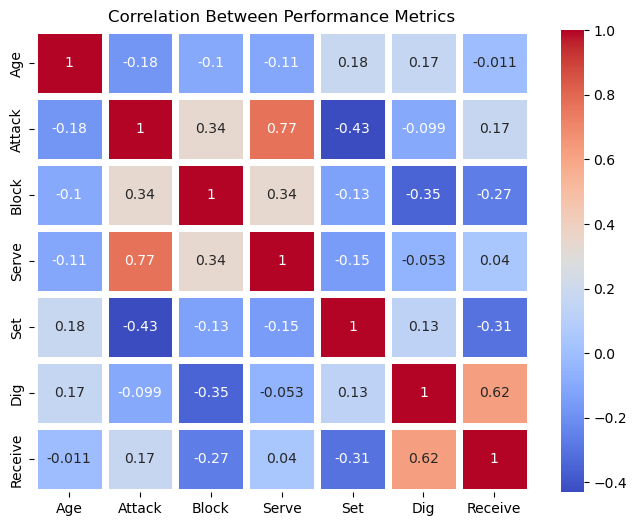

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidth = 5)
plt.title('Correlation Between Performance Metrics')
plt.show()

- Attack and Block show a moderate positive correlation (0.34): This indicates a positive relationship where players strong in attack often contribute to blocking, though the link isn't as definitive as other power metrics.

- Serve has a high correlation with Attack (0.77) but a low correlation with most other metrics: While it is strongly tied to attacking power, its low correlation with defensive stats like Dig (-0.053) and Receive (0.04) suggests it is an independent skill from the defensive side of the game.

- Dig shows a strong relationship with Receive (0.62) but no strong relationship with offensive metrics: It is negatively correlated with Attack (-0.099) and Block (-0.35), confirming that defensive performance is a specialized skill set distinct from offensive outpu

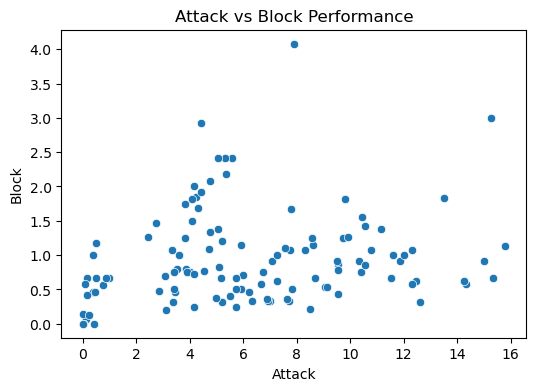

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Attack', y='Block', data=df)
plt.title('Attack vs Block Performance')
plt.xlabel('Attack')
plt.ylabel('Block')
plt.show()

### Insight:
- There is a weak upward trend between Attack and Block
- Players with higher attack values tend to have higher values: However, many high-attack players still have relatively low block scores.
- The spread suggests weak relationship between the two variables

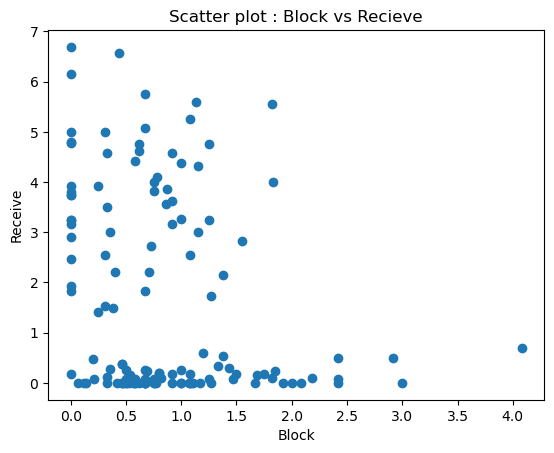

In [20]:
plt.scatter(df['Block'], df['Receive'])
plt.title('Scatter plot : Block vs Recieve')
plt.xlabel('Block')
plt.ylabel('Receive')
plt.show()

# insights
- The L-Shape Distribution: The way the points hug the Y-axis (high Receive, low Block) and the X-axis (high Block, low Receive) is a classic indicator of specialization.

- The "All-Rounders": The players in the middle of the "cloud" (e.g., Block between 0.5–1.0 and Receive between 3–5) are likely Outside Hitters, who are expected to contribute in both areas.


## Multivariate Analysis

In this section, we analyze performance metrics across multiple factors such as country, player position, and age to uncover deeper patterns.

In [21]:
avg_attack_by_country = df.groupby('Country')['Attack'].mean().sort_values(ascending=False)
avg_attack_by_country

Country
France       6.670000
Japan        6.595000
Cuba         6.344286
Serbia       5.998750
Italy        5.965000
Slovenia     5.961250
Argentina    5.925000
Nederland    5.880000
Poland       5.807000
Canada       5.405714
Bulgaria     5.282500
Brazil       5.250000
China        5.093750
Germany      4.833750
Iran         4.707778
USA          4.600000
Name: Attack, dtype: float64

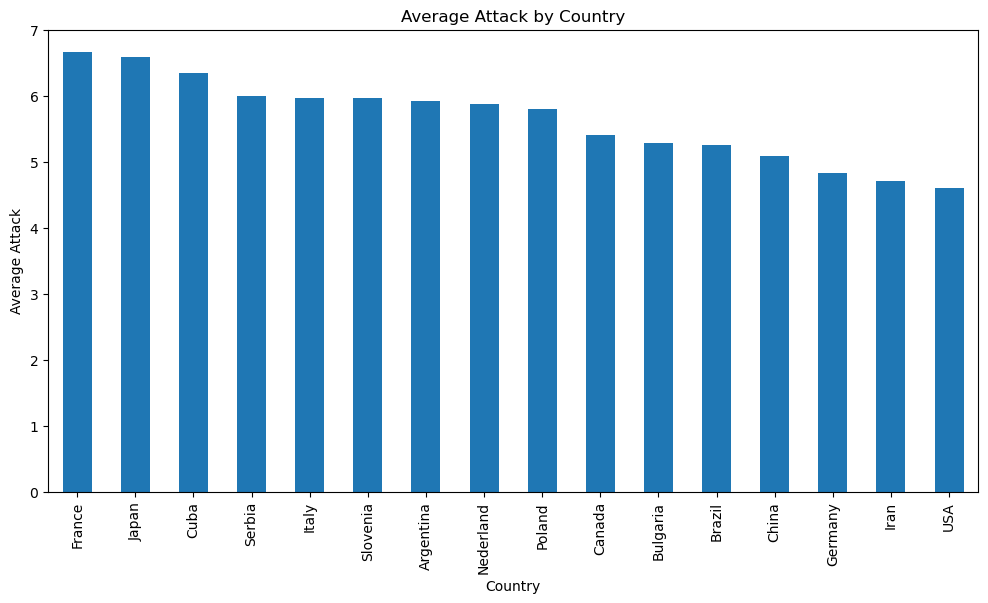

In [22]:
avg_attack_by_country.plot(kind='bar', figsize=(12, 6))
plt.title('Average Attack by Country')
plt.xlabel('Country')
plt.ylabel('Average Attack')
plt.show()

### Insight:
- Certain countries consistently outperform others in attack performance, france and japan as the top two
- There is variation across countries in all performance metrics
- This may reflect differences in training, play style, or team strategy

In [23]:
avg_serve_by_age = df.groupby('Age')['Serve'].mean().sort_values(ascending=False)
avg_serve_by_age

Age
31    0.910000
20    0.880000
21    0.770000
26    0.681053
28    0.667273
35    0.666667
27    0.662500
36    0.660000
24    0.640667
22    0.534286
23    0.526667
29    0.477500
30    0.429231
38    0.400000
33    0.321429
32    0.290000
37    0.270000
19    0.200000
25    0.165714
34    0.026667
41    0.000000
Name: Serve, dtype: float64

# insight
- There is (no linear / a non-linear) relationship between Age and Serve performance.

- The highest average serve values are found in players aged 31 and 20, while the lowest are found in the oldest (41) and certain mid-range ages (25, 34).

- This confirms that Age is not a consistent predictor of serving success, as high performance is scattered across the 20s and early 30s.

In [24]:
df.groupby(['Country', 'Position'])['Attack'].max().reset_index().sort_values(by='Attack', ascending=False).head(20)

,Country,Position,Attack
52,Japan,OH,15.80
58,Nederland,OP,15.33
33,France,OP,15.25
28,Cuba,OP,15.00
68,Serbia,OP,14.33
12,Bulgaria,OH,14.25
22,China,OH,13.50
72,Slovenia,OH,12.62
8,Brazil,OP,12.46
48,Italy,OP,12.33


# insight
The peak attack performance is dominated by the Outside Hitter (OH) and Opposite (OP) positions, with Japan leading the dataset with a score of 15.80. This granular view identifies the specific sources of the 'outlier' values seen in the general attack distribution, confirming that elite scoring is a function of specific positional roles rather than being evenly distributed across the team."

In [25]:
df.groupby('Country')['Dig'].sum().sort_values(ascending=False).head(10)

Country
France       38.59
Italy        35.89
Argentina    33.88
Slovenia     33.85
Poland       32.56
Japan        32.38
Serbia       30.64
USA          28.42
Canada       26.50
Brazil       24.61
Name: Dig, dtype: float64

# insight
- France (38.59) and Italy (35.89) lead the dataset in Dig

In [26]:
df.columns

Index(['Player', 'Country', 'Age', 'Attack', 'Block', 'Serve', 'Set', 'Dig',
       'Receive', 'Position'],
      dtype='object')

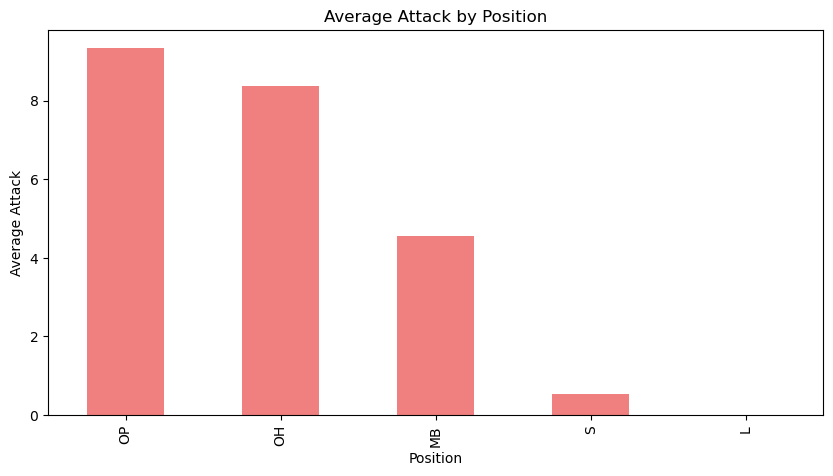

In [27]:
avg_attack_by_position = df.groupby('Position')['Attack'].mean().sort_values(ascending=False)

avg_attack_by_position.plot(kind='bar',color = 'lightcoral', figsize=(10, 5))
plt.title('Average Attack by Position')
plt.xlabel('Position')
plt.ylabel('Average Attack')    
plt.show()

# insights
- the primary scorers are OP and OH
- the hybrid role (MB): maintains a moderate attack of approximately 4.5
- S and L have little to no impact on the attack

In [28]:
total_attack_block_by_country = df.groupby('Country')[['Attack', 'Block']].sum()

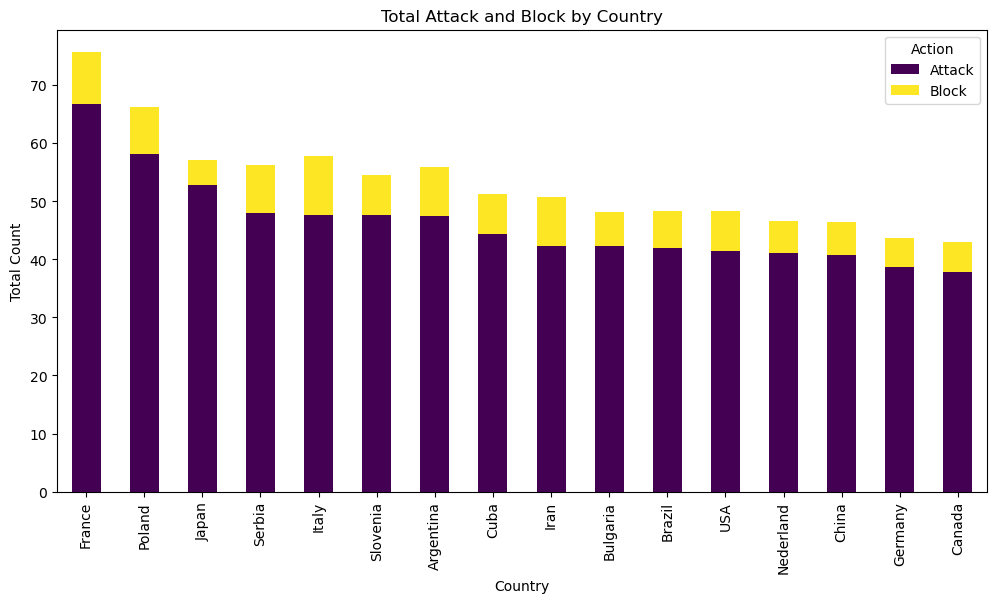

In [29]:
total_attack_block_by_country.sort_values(by = 'Attack', ascending=False).plot(kind = 'bar', stacked = True, figsize=(12, 6), colormap = 'viridis')
plt.title('Total Attack and Block by Country')
plt.xlabel('Country')
plt.ylabel('Total Count')
plt.legend(title='Action')
plt.show()

Geographic Dominance: France, Poland, and Japan are the dominant forces in this dataset for total point production.

Skill Priority: Regardless of country, Attack performance is the primary driver of total score, consistently contributing 70–80% of the total value.

Consistency: The bottom-tier countries (Germany, Canada) still maintain the same ratio of Attack-to-Block as the top-tier countries, showing that the style of play is consistent globally, even if the volume of points differs.

### Final Insights: 
Performance Patterns in the VNL 2023Positional Specialization is the Primary Driver: The analysis confirms that performance is strictly tied to player roles. Opposite Hitters (OP) and Outside Hitters (OH) act as the "offensive engines" with the highest average attacks ($>8.0$), while Middle Blockers (MB) represent the "defensive wall" at the net.The "Power" Connection: There is a strong positive correlation (0.77) between Attack and Serve performance. This indicates that raw physical power is a transferable skill; players who can spike the ball effectively are statistically the most likely to deliver high-value serves.The Defensive Trade-off: A clear negative correlation exists between Block and Receive/Dig metrics. This highlights the physical and strategic split in volleyball: players are either focused on front-row net defense or back-row floor defense, but rarely excel at both simultaneously.Age is a Non-Factor for Success: Contrary to the assumption that younger players might dominate, the data shows very weak correlations between Age and any performance metric. High performance is achieved by both "rising stars" (age 20) and "veterans" (age 31), suggesting that experience and physical prime are well-balanced in this league.France’s Global Dominance: France emerged as the most well-rounded team in the dataset, ranking #1 in total offensive points (Attack + Block) and #1 in total defensive Digs.
### Conclusion
The exploratory data analysis of the 2023 Volleyball Nations League dataset reveals a highly specialized and competitive landscape.While Attack performance remains the most common way to score points, it is the most skewed metric, with only a small "elite" group of players (largely from Japan, Nederland, and France) reaching peak efficiency. The findings suggest that team success is not just about having the hardest hitters, but about balancing specialized roles—the "power hitters" (OH/OP) who drive the offensive peaks, and the "scrappy" defensive units (seen in teams like Italy and Argentina) that sustain rallies through high dig volumes.Ultimately, this analysis proves that volleyball is a game of trade-offs: power and service are linked, but net defense and floor defense remain distinct, specialized crafts.